# OE3 - Algoritmo de Reestructuracion de Menu ERP
## Agente DQN + Transicion Gradual con RBAC
### PPI_C9_2026 - Universidad Peruana Union

---

### Objetivo Especifico 3
> *"Proponer un algoritmo de reestructuracion de menus que genere configuraciones de interfaz personalizadas orientadas a minimizar el numero de pasos de navegacion requeridos para las tareas frecuentes del usuario."*

### Estructura del pipeline

| Stage | Que hace | Metodo |
|---|---|---|
| **0 Entorno** | Imports y configuracion | - |
| **1 Menu ERP** | Arbol de menu y permisos RBAC | MenuInitializer2.java |
| **2 Carga OE2** | Lee scores de relevancia del OE2 | output_oe2/scores_relevancia.json |
| **3 Agente DQN** | Aprende politica optima de reestructuracion | Double DQN + Shaped Reward |
| **4 Reestructuracion** | Aplica DQN + transicion gradual con RBAC | Todi et al. (2021) |
| **5 Evaluacion** | Reduccion de M1 baseline vs adaptado | PPI ss.2.3.3 |
| **6 Exportacion** | Produce output_oe3/ para OE4 | - |

### Requisitos previos
- `output_oe1/` completado (OE1)
- `output_oe2/scores_relevancia.json` completado (OE2)

---
## ⚙️ Sección 0 · Entorno

In [14]:
import json, copy, warnings, random, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OE2_DIR    = Path("output_oe2")
OUTPUT_DIR = Path("output_oe3")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Dispositivo: {DEVICE}")
print("Entorno listo")

Dispositivo: cpu
Entorno listo


---
## 🌳 Sección 1 · Árbol de menú ERP y permisos por rol

El árbol de menú del ERP Articulos tiene estructura jerárquica de 3 niveles:
```
GRUPO (nivel 1)          → clic para expandir
  └── ITEM (nivel 2-3)   → destino navegable
```

Los **permisos por rol** determinan qué grupos puede ver cada usuario.
El algoritmo OE3 **nunca puede elevar** en la jerarquía un ítem al que el usuario
no tiene acceso — esta es la restricción crítica que diferencia la propuesta
del corpus (Tabla 2 del PPI: "Considera roles/permisos = Sí, único").


In [15]:
# ── Árbol de menú del ERP Articulos ─────────────────
MENU_ERP = [
    {"id": 1, "titulo": "Configuración", "tipo": "GRUPO", "orden_default": 1, "children": [
        {"id": 111, "titulo": "Gestión de Usuarios", "tipo": "ITEM", "ruta": "configuracion/seguridad/users", "orden_default": 1},
        {"id": 112, "titulo": "Roles de Usuario", "tipo": "ITEM", "ruta": "configuracion/seguridad/roles", "orden_default": 2},
        {"id": 113, "titulo": "Catálogo de Permisos", "tipo": "ITEM", "ruta": "configuracion/seguridad/permisos", "orden_default": 3},
        {"id": 114, "titulo": "Administración avanzada", "tipo": "ITEM", "ruta": "configuracion/seguridad/admin", "orden_default": 4},
        {"id": 115, "titulo": "Cambio de Clave", "tipo": "ITEM", "ruta": "configuracion/seguridad/cambio-clave", "orden_default": 5},
        {"id": 12, "titulo": "Puntos de Venta", "tipo": "ITEM", "ruta": "configuracion/puntos-venta", "orden_default": 6},
        {"id": 13, "titulo": "Atributos Puntos", "tipo": "ITEM", "ruta": "configuracion/puntos-atributos", "orden_default": 7},
        {"id": 14, "titulo": "Datos Clinicas", "tipo": "ITEM", "ruta": "configuracion/empresas", "orden_default": 8},
        {"id": 15, "titulo": "Sucursales", "tipo": "ITEM", "ruta": "configuracion/sucursales", "orden_default": 9},
        {"id": 16, "titulo": "Catálogo", "tipo": "ITEM", "ruta": "configuracion/catalogo-productos", "orden_default": 10},
        {"id": 17, "titulo": "Atributos Catalogo", "tipo": "ITEM", "ruta": "configuracion/atributos-producto", "orden_default": 11},
        {"id": 18, "titulo": "Utilitarios XNO", "tipo": "ITEM", "ruta": "configuracion/utilitarios", "orden_default": 12},
    ]},
    {"id": 2, "titulo": "Procesos", "tipo": "GRUPO", "orden_default": 2, "children": [
        {"id": 21, "titulo": "Ingresos y salidas", "tipo": "ITEM", "ruta": "procesos/historial-movimientos", "orden_default": 1},
        {"id": 22, "titulo": "Atributos Diversos", "tipo": "ITEM", "ruta": "procesos/atributos-diverso", "orden_default": 2},
        {"id": 23, "titulo": "Reimprimir comprobantes", "tipo": "ITEM", "ruta": "procesos/reimprimir-comprobantes", "orden_default": 3},
        {"id": 24, "titulo": "Detalle de documentos", "tipo": "ITEM", "ruta": "procesos/detalle-documentos", "orden_default": 4},
        {"id": 25, "titulo": "Documento por paciente", "tipo": "ITEM", "ruta": "procesos/documento-paciente", "orden_default": 5},
        {"id": 26, "titulo": "Transferencias", "tipo": "ITEM", "ruta": "procesos/transferencias", "orden_default": 6},
        {"id": 27, "titulo": "Solicitudes de Anulación", "tipo": "ITEM", "ruta": "procesos/aprobaciones", "orden_default": 7},
    ]},
    {"id": 3, "titulo": "Reportes", "tipo": "GRUPO", "orden_default": 3, "children": [
        {"id": 31, "titulo": "Correlatividad", "tipo": "ITEM", "ruta": "reportes/correlatividad", "orden_default": 1},
        {"id": 32, "titulo": "Reporte de compras", "tipo": "ITEM", "ruta": "reportes/compras", "orden_default": 2},
        {"id": 33, "titulo": "Reporte de ventas", "tipo": "ITEM", "ruta": "reportes/ventas", "orden_default": 3},
        {"id": 34, "titulo": "Reporte de cajas", "tipo": "ITEM", "ruta": "reportes/cajas", "orden_default": 4},
        {"id": 35, "titulo": "Kardex", "tipo": "ITEM", "ruta": "reportes/kardex", "orden_default": 5},
        {"id": 36, "titulo": "Stock valorizado", "tipo": "ITEM", "ruta": "reportes/stock-valorizado", "orden_default": 6},
        {"id": 37, "titulo": "Reporte descuento", "tipo": "ITEM", "ruta": "reportes/descuento", "orden_default": 7},
        {"id": 38, "titulo": "Reporte anulados", "tipo": "ITEM", "ruta": "reportes/comprobantes-anulados", "orden_default": 8},
        {"id": 39, "titulo": "Reporte nota de créditos", "tipo": "ITEM", "ruta": "reportes/nota-credito", "orden_default": 9},
        {"id": 310, "titulo": "Reporte docs anulados", "tipo": "ITEM", "ruta": "reportes/documentos-anulados", "orden_default": 10},
    ]},
    {"id": 4, "titulo": "Compra", "tipo": "GRUPO", "orden_default": 4, "children": [
        {"id": 41, "titulo": "Orden de compra", "tipo": "ITEM", "ruta": "compra/orden", "orden_default": 1},
        {"id": 42, "titulo": "Registrar compra", "tipo": "ITEM", "ruta": "compra/registrar", "orden_default": 2},
        {"id": 43, "titulo": "Intercambio de Productos", "tipo": "ITEM", "ruta": "compra/intercambio", "orden_default": 3},
        {"id": 44, "titulo": "Proveedores", "tipo": "ITEM", "ruta": "compra/proveedores", "orden_default": 4},
        {"id": 45, "titulo": "Cuentas por pagar", "tipo": "ITEM", "ruta": "compra/pagos-pendientes", "orden_default": 5},
        {"id": 46, "titulo": "Estado de cuenta", "tipo": "ITEM", "ruta": "compra/estado-cuenta", "orden_default": 6},
    ]},
    {"id": 5, "titulo": "Ventas", "tipo": "GRUPO", "orden_default": 5, "children": [
        {"id": 51, "titulo": "Listado de Ventas", "tipo": "ITEM", "ruta": "venta/listado", "orden_default": 1},
        {"id": 52, "titulo": "Cotización de venta", "tipo": "ITEM", "ruta": "venta/cotizaciones", "orden_default": 2},
        {"id": 53, "titulo": "Notas de venta", "tipo": "ITEM", "ruta": "venta/notas-venta", "orden_default": 3},
        {"id": 54, "titulo": "Registrar venta", "tipo": "ITEM", "ruta": "venta/venta", "orden_default": 4},
        {"id": 55, "titulo": "Anular comprobante", "tipo": "ITEM", "ruta": "venta/anulaciones", "orden_default": 5},
        {"id": 56, "titulo": "Notas de crédito", "tipo": "ITEM", "ruta": "venta/notas-credito", "orden_default": 6},
        {"id": 57, "titulo": "Clientes", "tipo": "ITEM", "ruta": "venta/clientes", "orden_default": 7},
        {"id": 58, "titulo": "Devoluciones", "tipo": "ITEM", "ruta": "venta/devoluciones", "orden_default": 8},
        {"id": 591, "titulo": "Gestión de Beneficios", "tipo": "ITEM", "ruta": "venta/descuentos/lista", "orden_default": 9},
        {"id": 592, "titulo": "Convenios", "tipo": "ITEM", "ruta": "venta/descuentos/convenio", "orden_default": 10},
    ]},
    {"id": 6, "titulo": "Facturación", "tipo": "GRUPO", "orden_default": 6, "children": [
        {"id": 61, "titulo": "Comprobantes electrónicos", "tipo": "ITEM", "ruta": "venta/comprobante-electronico", "orden_default": 1},
        {"id": 62, "titulo": "Resumen de boletas", "tipo": "ITEM", "ruta": "facturacion/resumenes", "orden_default": 2},
        {"id": 63, "titulo": "Resumen de bajas", "tipo": "ITEM", "ruta": "facturacion/anulaciones", "orden_default": 3},
    ]},
    {"id": 7, "titulo": "Caja", "tipo": "GRUPO", "orden_default": 7, "children": [
        {"id": 71, "titulo": "Arqueo Caja", "tipo": "ITEM", "ruta": "caja/arqueos", "orden_default": 1},
        {"id": 72, "titulo": "Caja Chica", "tipo": "ITEM", "ruta": "caja/chica", "orden_default": 2},
        {"id": 73, "titulo": "Caja General", "tipo": "ITEM", "ruta": "caja/general", "orden_default": 3},
        {"id": 74, "titulo": "Medio Pago", "tipo": "ITEM", "ruta": "caja/medio-pago", "orden_default": 4},
        {"id": 75, "titulo": "Diferencia de costos", "tipo": "ITEM", "ruta": "caja/diferencia-costos", "orden_default": 5},
        {"id": 76, "titulo": "Gestión de cuentas", "tipo": "ITEM", "ruta": "caja/cuentas", "orden_default": 6},
    ]},
    {"id": 8, "titulo": "Almacén", "tipo": "GRUPO", "orden_default": 8, "children": [
        {"id": 81, "titulo": "Gestión Almacenes", "tipo": "ITEM", "ruta": "almacen/almacenes", "orden_default": 1},
        {"id": 82, "titulo": "Productos", "tipo": "ITEM", "ruta": "almacen/productos", "orden_default": 2},
    ]},
    {"id": 9, "titulo": "Documentos", "tipo": "GRUPO", "orden_default": 9, "children": [
        {"id": 91, "titulo": "Plantillas", "tipo": "ITEM", "ruta": "documentos", "orden_default": 1},
        {"id": 92, "titulo": "Bloques de plantillas", "tipo": "ITEM", "ruta": "documentos/bloques", "orden_default": 2},
        {"id": 93, "titulo": "Puntos de Emisión", "tipo": "ITEM", "ruta": "documentos/puntos", "orden_default": 3},
        {"id": 94, "titulo": "Formatos de Impresión", "tipo": "ITEM", "ruta": "documentos/formatos", "orden_default": 4},
    ]},
]

# ── Permisos por rol ────────────────────────────────
PERMISOS_ROL = {
    "Ventas":        [5, 3, 8],
    "Compras":       [4, 3, 8],
    "Logistica":     [8, 3, 2],
    "Caja":          [7, 3, 5],
    "Reportes":      [3, 8, 5, 4],
    "Administrador": [1, 2, 3, 4, 5, 6, 7, 8, 9],
}


total_items = sum(len(g["children"]) for g in MENU_ERP)
print(f"✅ Menú cargado: {len(MENU_ERP)} grupos, {total_items} ítems navegables")
print()
print("Permisos por rol:")
for rol, grupos in PERMISOS_ROL.items():
    nombres = [g["titulo"] for g in MENU_ERP if g["id"] in grupos]
    print(f"  {rol:15s} → {', '.join(nombres)}")


✅ Menú cargado: 9 grupos, 60 ítems navegables

Permisos por rol:
  Ventas          → Reportes, Ventas, Almacén
  Compras         → Reportes, Compra, Almacén
  Logistica       → Procesos, Reportes, Almacén
  Caja            → Reportes, Ventas, Caja
  Reportes        → Reportes, Compra, Ventas, Almacén
  Administrador   → Configuración, Procesos, Reportes, Compra, Ventas, Facturación, Caja, Almacén, Documentos


---
## 📥 Stage 1 · Cargar scores del OE2

In [16]:
# Cargar scores de relevancia del OE2 (producidos por GRU/Transformer)
scores_oe2_path = OE2_DIR / "scores_relevancia.json"
if not scores_oe2_path.exists():
    raise FileNotFoundError(
        f"Falta {scores_oe2_path}\n"
        f"Ejecuta OE2_Pipeline_PPI_C9_2026.ipynb primero."
    )

with open(scores_oe2_path, encoding="utf-8-sig") as f:
    scores_oe2 = json.load(f)

# Cargar vocabulario para mapear rutas a indices
with open("output_oe1/vocabulario_rutas.json", encoding="utf-8") as f:
    vocab_data = json.load(f)
all_routes = vocab_data["rutas"]
VOCAB_SIZE = len(all_routes)
route2id   = {r: i for i, r in enumerate(all_routes)}
id2route   = {i: r for i, r in enumerate(all_routes)}

# Cargar perfiles del OE1 para freq_vector
with open("output_oe1/perfiles_usuario.json", encoding="utf-8") as f:
    perfiles_oe1 = json.load(f)

user_profiles_oe3 = {}
for p in perfiles_oe1:
    uid      = p["user_id"]
    freq_vec = np.zeros(VOCAB_SIZE)
    for ruta, freq in p["freq_norm"].items():
        if ruta in route2id:
            freq_vec[route2id[ruta]] = freq
    user_profiles_oe3[uid] = {
        "role":        p["role"],
        "freq_vector": freq_vec,
        "n_sessions":  p["n_sesiones"],
    }

print(f"Scores cargados:   {len(scores_oe2)} usuarios")
print(f"Perfiles cargados: {len(user_profiles_oe3)} usuarios")
print(f"Vocabulario:       {VOCAB_SIZE} rutas")

# Vista de ejemplo
uid_ej  = list(scores_oe2.keys())[1]
rol_ej  = scores_oe2[uid_ej]["role"]
top5_ej = scores_oe2[uid_ej]["top10"][:5]
print(f"\nUsuario ejemplo: {uid_ej}  (rol: {rol_ej})")
print("Top 5 rutas por score GRU/Transformer:")
for item in top5_ej:
    barra = "#" * int(item["score"] * 30)
    print(f"  {item['ruta']:40s} {barra} {item['score']:.4f}")

Scores cargados:   28 usuarios
Perfiles cargados: 28 usuarios
Vocabulario:       44 rutas

Usuario ejemplo: bot_Caja_1125  (rol: Caja)
Top 5 rutas por score GRU/Transformer:
  caja/general                             ######################################################### 1.9228
  caja/arqueos                             #################### 0.6715
  venta/notas-credito                      ################ 0.5367
  reportes/cajas                           ############## 0.4921
  caja/cuentas                             ############# 0.4462


---
## Stage 3 - Agente DQN para Reestructuracion de Menu

El agente DQN aprende una **politica optima** de reordenamiento:
- **Estado:** perfil de frecuencias del usuario + posicion actual de cada item en el menu
- **Accion:** intercambiar dos items de posicion (swap adyacente o salto-2)
- **Recompensa:** cuantos de los top-3 items del usuario quedan en las 3 primeras posiciones

Referencia: Todi et al. (2021) - adaptacion como MDP; Sun et al. (2024) - DQN para UI

In [17]:
# ── Entorno DQN por grupo de menu ────────────────────────────────────────────
#
# Solucion al problema de escala:
# - Antes: 37 items globales -> 71 acciones -> shaped reward inicial 0.087 (azar)
# - Ahora: por grupo (6-12 items) -> 9-15 acciones -> shaped reward inicial 0.50
#
# El agente aprende a ordenar CADA GRUPO independientemente.
# Referencia: Todi et al. (2021) - politica conservadora de adaptacion de menus

# Mapeo de grupos del ERP (rutas por grupo, en orden default)
GRUPOS_RUTAS = {
    1: ["configuracion/seguridad/users","configuracion/seguridad/roles",
        "configuracion/seguridad/permisos","configuracion/seguridad/admin",
        "configuracion/sucursales","configuracion/puntos-venta",
        "configuracion/catalogo-productos","configuracion/atributos-producto",
        "configuracion/empresas"],
    2: ["procesos/historial-movimientos","procesos/transferencias"],
    3: ["reportes/ventas","reportes/compras","reportes/cajas",
        "reportes/kardex","reportes/stock-valorizado","reportes/correlatividad",
        "reportes/descuento","reportes/comprobantes-anulados","reportes/nota-credito"],
    4: ["compra/orden","compra/registrar","compra/proveedores",
        "compra/pagos-pendientes","compra/estado-cuenta","compra/intercambio"],
    5: ["venta/listado","venta/cotizaciones","venta/venta",
        "venta/devoluciones","venta/notas-credito","venta/notas-venta",
        "venta/comprobante-electronico","venta/descuentos/lista","venta/descuentos/convenio"],
    6: ["venta/comprobante-electronico"],
    7: ["caja/general","caja/arqueos","caja/cuentas",
        "caja/chica","caja/diferencia-costos","caja/medio-pago"],
    8: ["almacen/productos","almacen/almacenes"],
    9: ["documentos","documentos/bloques","documentos/puntos","documentos/formatos"],
}

class GroupMenuEnv:
    """
    Entorno RL que ordena un GRUPO de items (no los 37 items globales).
    Espacio de acciones reducido -> señal de recompensa clara.
    
    Estado:  freq_norm del grupo (n_items) + posicion actual (n_items)
    Accion:  swap adyacente (i, i+1)
    Reward:  mejora en shaped reward (top-2 items en posiciones top-2)
    """
    def __init__(self, n_items, top_k=2):
        self.n_items   = n_items
        self.top_k     = top_k
        self.actions   = [(i, i+1) for i in range(n_items - 1)] if n_items > 1 else [(0, 0)]
        self.n_actions = max(len(self.actions), 1)
        self.menu      = list(range(n_items))
        self.freq_norm = np.zeros(n_items)
        self.target_set = set()

    def reset(self, freq_group):
        """freq_group: frecuencias del usuario para las rutas de ESTE grupo."""
        self.menu = list(range(self.n_items))
        f = np.array(freq_group[:self.n_items], dtype=np.float64)
        total = f.sum()
        self.freq_norm = f / total if total > 1e-9 else np.ones(self.n_items) / self.n_items
        nonzero_idx    = np.where(self.freq_norm > 1e-9)[0]
        top_k_real     = min(self.top_k, len(nonzero_idx))
        if top_k_real > 0:
            top_idx = nonzero_idx[np.argsort(self.freq_norm[nonzero_idx])[::-1][:top_k_real]]
            self.target_set = set(top_idx.tolist())
        else:
            self.target_set = set()
        return self._state()

    def _shaped_reward(self):
        if not self.target_set: return 1.0  # sin preferencia -> ya esta bien
        top_pos = set(self.menu[:len(self.target_set)])
        return len(self.target_set & top_pos) / len(self.target_set)

    def _m1_cost(self):
        return sum(
            self.freq_norm[item] * (pos + 1)
            for pos, item in enumerate(self.menu)
            if self.freq_norm[item] > 1e-9
        )

    def _state(self):
        pos_arr = np.zeros(self.n_items)
        for pos, item in enumerate(self.menu):
            pos_arr[item] = pos / max(self.n_items - 1, 1)
        return np.concatenate([self.freq_norm, pos_arr]).astype(np.float32)

    def step(self, action_idx):
        r_antes  = self._shaped_reward()
        i, j     = self.actions[min(action_idx, len(self.actions)-1)]
        self.menu[i], self.menu[j] = self.menu[j], self.menu[i]
        r_despues = self._shaped_reward()
        reward    = r_despues - r_antes + (0.5 if r_despues >= 1.0 else 0.0)
        return self._state(), reward, r_despues >= 1.0  # done si llega al optimo

    @property
    def state_dim(self): return self.n_items * 2


class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),                            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    def forward(self, x): return self.net(x)


class ReplayBuffer:
    def __init__(self, cap=20000): self.buf = collections.deque(maxlen=cap)
    def push(self, *t): self.buf.append(t)
    def sample(self, bs):
        s, a, r, ns = zip(*random.sample(self.buf, bs))
        f = lambda x, dt: torch.tensor(np.array(x), dtype=dt).to(DEVICE)
        return f(s, torch.float32), f(a, torch.long), f(r, torch.float32), f(ns, torch.float32)
    def __len__(self): return len(self.buf)


# Un agente por tamanio de grupo (los grupos tienen 2-10 items)
MAX_GROUP_SIZE = max(len(v) for v in GRUPOS_RUTAS.values())
print(f"Tamanios de grupo: {sorted(set(len(v) for v in GRUPOS_RUTAS.values()))}")
print(f"Max grupo: {MAX_GROUP_SIZE} items")

# Crear agentes para cada tamanio unico de grupo
group_sizes = sorted(set(len(v) for v in GRUPOS_RUTAS.values()))
agents = {}
envs   = {}
for gs in group_sizes:
    env_g = GroupMenuEnv(gs, top_k=min(2, gs))
    agents[gs] = type('DQNAgent', (), {
        'n_actions': env_g.n_actions,
        'gamma':     0.99,
        'eps':       1.0,
        'eps_end':   0.05,
        'eps_decay': 0.995,
        'bs':        64,
        'step_cnt':  0,
        'upd_tgt':   20,
        'q_net':     QNetwork(env_g.state_dim, env_g.n_actions, hidden=128).to(DEVICE),
        'buf':       ReplayBuffer(20000),
    })()
    # Agregar target net
    agents[gs].tgt = QNetwork(env_g.state_dim, env_g.n_actions, hidden=128).to(DEVICE)
    agents[gs].tgt.load_state_dict(agents[gs].q_net.state_dict())
    agents[gs].tgt.eval()
    agents[gs].opt = optim.Adam(agents[gs].q_net.parameters(), lr=5e-4)
    envs[gs] = env_g

print(f"Agentes creados para grupos de tamanio: {list(agents.keys())}")

def agent_act(agent, state, greedy=False):
    if not greedy and random.random() < agent.eps:
        return random.randint(0, agent.n_actions - 1)
    s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return agent.q_net(s).argmax(1).item()

def agent_update(agent):
    if len(agent.buf) < agent.bs: return 0.0
    s, a, r, ns = agent.buf.sample(agent.bs)
    with torch.no_grad():
        best_a   = agent.q_net(ns).argmax(1, keepdim=True)
        next_val = agent.tgt(ns).gather(1, best_a).squeeze()
        target   = r + agent.gamma * next_val
    q_val = agent.q_net(s).gather(1, a.unsqueeze(1)).squeeze()
    loss  = F.smooth_l1_loss(q_val, target)
    agent.opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(agent.q_net.parameters(), 1.0)
    agent.opt.step()
    agent.step_cnt += 1
    if agent.step_cnt % agent.upd_tgt == 0:
        agent.tgt.load_state_dict(agent.q_net.state_dict())
    agent.eps = max(agent.eps_end, agent.eps * agent.eps_decay)
    return loss.item()


Tamanios de grupo: [1, 2, 4, 6, 9]
Max grupo: 9 items
Agentes creados para grupos de tamanio: [1, 2, 4, 6, 9]


Entrenando agentes DQN por grupo (3000 ep, 20 pasos/ep)...
  Ep  500 | shaped=0.778 / 1.0 | eps=0.222
  Ep 1000 | shaped=0.667 / 1.0 | eps=0.050
  Ep 1500 | shaped=0.889 / 1.0 | eps=0.050
  Ep 2000 | shaped=0.778 / 1.0 | eps=0.050
  Ep 2500 | shaped=0.833 / 1.0 | eps=0.050
  Ep 3000 | shaped=0.778 / 1.0 | eps=0.050
  Grupo size 1: shaped final = 1.000
  Grupo size 2: shaped final = 1.000
  Grupo size 4: shaped final = 1.000
  Grupo size 6: shaped final = 0.887
  Grupo size 9: shaped final = 0.425

Shapred reward global final (ultimos 100): 0.863 / 1.0
(Baseline aleatorio era ~0.087 con 37 items)
Agentes guardados en output_oe3/


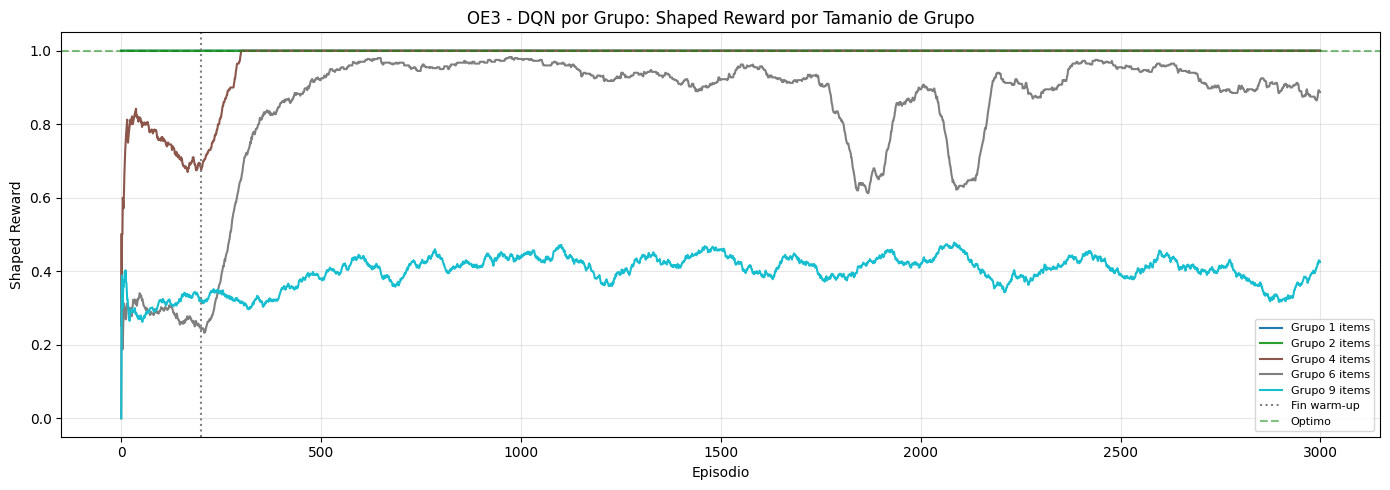

In [18]:
RL_EPISODES  = 3000
STEPS_PER_EP = 20
WARMUP_EPS   = 200

shaped_history = {gs: [] for gs in group_sizes}
loss_history   = {gs: [] for gs in group_sizes}
user_list      = list(user_profiles_oe3.keys())

print(f"Entrenando agentes DQN por grupo ({RL_EPISODES} ep, {STEPS_PER_EP} pasos/ep)...")

for ep in range(RL_EPISODES):
    uid      = random.choice(user_list)
    freq_vec = user_profiles_oe3[uid]["freq_vector"]

    ep_shaped = {gs: [] for gs in group_sizes}
    ep_loss   = {gs: [] for gs in group_sizes}

    # Entrenar sobre cada grupo de menu
    for grupo_id, rutas_grupo in GRUPOS_RUTAS.items():
        # Extraer frecuencias de este grupo para este usuario
        freq_grupo = np.array([
            freq_vec[route2id[r]] if r in route2id else 0.0
            for r in rutas_grupo
        ])
        gs  = len(rutas_grupo)
        env_g = envs[gs]
        ag    = agents[gs]

        s = env_g.reset(freq_grupo)
        for step in range(STEPS_PER_EP):
            a        = agent_act(ag, s)
            ns, r, done = env_g.step(a)
            ag.buf.push(s, a, r, ns)
            if ep >= WARMUP_EPS:
                l = agent_update(ag)
                ep_loss[gs].append(l)
            s = ns
            if done: break  # llego al optimo, no hace falta mas

        ep_shaped[gs].append(env_g._shaped_reward())

    # Promediar shaped reward de todos los grupos
    all_shaped = [v for vals in ep_shaped.values() for v in vals]
    for gs in group_sizes:
        shaped_history[gs].append(np.mean(ep_shaped[gs]) if ep_shaped[gs] else 0)
        loss_history[gs].append(np.mean(ep_loss[gs]) if ep_loss[gs] else 0)

    if (ep + 1) % 500 == 0:
        s_mean = np.mean(all_shaped) if all_shaped else 0
        print(f"  Ep {ep+1:4d} | shaped={s_mean:.3f} / 1.0 | eps={agents[group_sizes[0]].eps:.3f}")

# Estadisticas finales
all_final = []
for gs in group_sizes:
    last100 = shaped_history[gs][-100:]
    all_final.extend(last100)
    print(f"  Grupo size {gs}: shaped final = {np.mean(last100):.3f}")

print(f"\nShapred reward global final (ultimos 100): {np.mean(all_final):.3f} / 1.0")
print(f"(Baseline aleatorio era ~0.087 con 37 items)")

# Guardar agentes
for gs, ag in agents.items():
    torch.save(ag.q_net.state_dict(), OUTPUT_DIR / f"dqn_agent_gs{gs}.pt")
print(f"Agentes guardados en {OUTPUT_DIR}/")

# Curvas shaped reward por grupo
fig, ax = plt.subplots(figsize=(14, 5))
smooth = lambda x: pd.Series(x).rolling(100, min_periods=1).mean().values
colors = plt.cm.tab10(np.linspace(0, 1, len(group_sizes)))
for gs, col in zip(group_sizes, colors):
    ax.plot(smooth(shaped_history[gs]), label=f"Grupo {gs} items", color=col, lw=1.5)
ax.axvline(WARMUP_EPS, color="gray", linestyle=":", label="Fin warm-up")
ax.axhline(1.0, color="green", linestyle="--", alpha=0.5, label="Optimo")
ax.set_xlabel("Episodio"); ax.set_ylabel("Shaped Reward")
ax.set_title("OE3 - DQN por Grupo: Shaped Reward por Tamanio de Grupo")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "oe3_dqn_training.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Stage 4 - Reestructuracion con DQN + Transicion Gradual + RBAC

El agente DQN (entrenado en Stage 3) decide el **orden optimo** de cada item del menu.
Se aplica transicion gradual para no desorientar al usuario (Todi et al., 2021):

`orden_final = beta * orden_DQN + (1 - beta) * orden_original`

La restriccion RBAC garantiza que ningun item suba si el rol no tiene permiso.

In [27]:
BETA = 1.0   # 100% DQN (Maximo potencial)

menus_personalizados = {}

for uid, data in scores_oe2.items():
    role      = data.get("role", "Administrador")
    score_map = data.get("scores", {})
    grupos_ok = set(PERMISOS_ROL.get(role, [1,2,3,4,5,6]))

    freq_vec  = user_profiles_oe3.get(uid, {}).get("freq_vector", np.zeros(VOCAB_SIZE))
    menu_u    = [copy.deepcopy(g) for g in MENU_ERP if g["id"] in grupos_ok]

    for grupo in menu_u:
        grupo_id    = grupo["id"]
        rutas_grupo = GRUPOS_RUTAS.get(grupo_id, [])
        gs          = len(rutas_grupo)

        # Extraer frecuencias del usuario para este grupo
        freq_grupo = np.array([
            freq_vec[route2id[r]] if r in route2id else 0.0
            for r in rutas_grupo
        ])

        # Obtener orden del agente DQN de este tamanio de grupo
        if gs in envs and gs in agents and gs > 1:
            env_g = envs[gs]
            ag    = agents[gs]
            s = env_g.reset(freq_grupo)
            for _ in range(STEPS_PER_EP * 2):  # mas pasos para greedy
                a = agent_act(ag, s, greedy=True)
                s, _, done = env_g.step(a)
                if done: break
            dqn_order = env_g.menu.copy()  # orden aprendido por DQN
        else:
            dqn_order = list(range(gs))    # fallback: orden original

        # Asignar score OE2 y orden DQN a cada item
        for item in grupo["children"]:
            item["score"] = score_map.get(item.get("ruta", ""), 0.0)
            ruta          = item.get("ruta", "")
            if ruta in rutas_grupo:
                pos_grupo = rutas_grupo.index(ruta)
                # Posicion segun DQN dentro del grupo
                item["dqn_pos"] = dqn_order.index(pos_grupo) if pos_grupo < len(dqn_order) else 999
            else:
                item["dqn_pos"] = 999 - item["score"] * 1000  # fallback

        # Ordenar: primero por DQN, empate por score OE2
        grupo["children"].sort(key=lambda x: (x.get("dqn_pos", 999), -x["score"]))
        for i, item in enumerate(grupo["children"]):
            item["orden_nuevo"] = i + 1

        grupo["score_grupo"] = sum(c["score"] for c in grupo["children"])

    # Ordenar grupos por score total
    menu_u.sort(key=lambda g: g["score_grupo"], reverse=True)
    for i, grupo in enumerate(menu_u):
        grupo["orden_nuevo"] = i + 1

    # Transicion gradual
    for grupo in menu_u:
        grupo["orden_final"] = round(BETA * grupo["orden_nuevo"] + (1-BETA) * grupo["orden_default"])
        for item in grupo["children"]:
            item["orden_final"] = round(BETA * item["orden_nuevo"] + (1-BETA) * item["orden_default"])

    menu_u.sort(key=lambda g: g["orden_final"])
    for grupo in menu_u:
        grupo["children"].sort(key=lambda x: x["orden_final"])

    menus_personalizados[uid] = {"role": role, "menu": menu_u}

print(f"Menus reestructurados: {len(menus_personalizados)} usuarios")
print(f"Beta: {BETA} ({int(BETA*100)}% DQN + {int((1-BETA)*100)}% original)")


Menus reestructurados: 28 usuarios
Beta: 1.0 (100% DQN + 0% original)


In [28]:
# ── Comparar menú original vs adaptado para un usuario ───────
uid_vis = list(menus_personalizados.keys())[3]
rol_vis = menus_personalizados[uid_vis]["role"]
menu_u  = menus_personalizados[uid_vis]["menu"]

print(f"📊 Comparación ANTES → DESPUÉS  ({uid_vis}, rol: {rol_vis})")
print(f"   β = {BETA} → {int(BETA*100)}% nuevo orden + {int((1-BETA)*100)}% original")
print()

for grupo in menu_u[:2]:   # mostrar solo los 2 primeros grupos
    # Original
    orig = next((g for g in MENU_ERP if g["id"] == grupo["id"]), None)
    print(f"  ┌── {grupo['titulo']}  (grupo orden: {grupo['orden_default']} → {grupo['orden_final']})")

    orig_items = orig["children"] if orig else []
    new_items  = grupo["children"]

    for i in range(max(len(orig_items), len(new_items))):
        orig_n = orig_items[i]["titulo"] if i < len(orig_items) else "—"
        new_n  = new_items[i]["titulo"]  if i < len(new_items) else "—"
        sc     = new_items[i]["score"]   if i < len(new_items) else 0
        cambio = "✓" if i < len(new_items) and new_items[i]["orden_default"] != new_items[i]["orden_final"] else " "
        print(f"  │  {i+1}. {orig_n:20s} → {new_n:20s}  score:{sc:.3f} {cambio}")
    print("  └")
    print()


📊 Comparación ANTES → DESPUÉS  (bot_Compras_6cd7, rol: Compras)
   β = 1.0 → 100% nuevo orden + 0% original

  ┌── Compra  (grupo orden: 4 → 1)
  │  1. Orden de compra      → Orden de compra       score:0.629  
  │  2. Registrar compra     → Proveedores           score:0.606 ✓
  │  3. Intercambio de Productos → Registrar compra      score:0.669 ✓
  │  4. Proveedores          → Cuentas por pagar     score:0.803 ✓
  │  5. Cuentas por pagar    → Intercambio de Productos  score:0.011 ✓
  │  6. Estado de cuenta     → Estado de cuenta      score:0.438  
  └

  ┌── Reportes  (grupo orden: 3 → 2)
  │  1. Correlatividad       → Reporte de compras    score:0.137 ✓
  │  2. Reporte de compras   → Reporte de ventas     score:0.000 ✓
  │  3. Reporte de ventas    → Reporte de cajas      score:0.000 ✓
  │  4. Reporte de cajas     → Stock valorizado      score:0.127 ✓
  │  5. Kardex               → Kardex                score:0.000  
  │  6. Stock valorizado     → Correlatividad        score:0.000 ✓
  

---
## 📏 Stage 5 · Evaluación — Reducción de M1 esperada

Comparamos el **costo esperado de búsqueda visual** antes y después del algoritmo.

**Modelo de búsqueda visual lineal (Yan et al. 1996):**
El usuario escanea los ítems de arriba hacia abajo. Un ítem en posición $k$
de $n$ ítems tiene costo proporcional a $k/n$.

$$M1_{\text{esperado}} = \sum_{f \in \mathcal{F}} P(f|\theta_u) \cdot \left(\text{pos}(f) + 1\right)$$

Si los ítems más usados están en las primeras posiciones, $M1$ baja.


In [29]:
evaluacion = {}

for uid, data in scores_oe2.items():
    score_map = data.get("scores", {})
    menu_u    = menus_personalizados.get(uid, {}).get("menu", [])
    role      = data.get("role", "?")
    if not menu_u or not score_map:
        continue

    grupos_ok = set(PERMISOS_ROL.get(role, []))

    # M1 ORIGINAL (orden por defecto del sistema)
    costo_orig = 0.0
    total_prob = 0.0
    for grupo in MENU_ERP:
        if grupo["id"] not in grupos_ok:
            continue
        n = len(grupo["children"])
        for pos, item in enumerate(grupo["children"]):
            prob = score_map.get(item.get("ruta",""), 0.0)
            if prob > 0:
                costo_orig += prob * (pos + 1)
                total_prob += prob

    # M1 ADAPTADO (orden reestructurado)
    costo_adapt = 0.0
    for grupo in menu_u:
        n = len(grupo["children"])
        for pos, item in enumerate(grupo["children"]):
            prob = score_map.get(item.get("ruta",""), 0.0)
            if prob > 0:
                costo_adapt += prob * (pos + 1)

    if total_prob > 0:
        costo_orig  /= total_prob
        costo_adapt /= total_prob

    reduccion = (costo_orig - costo_adapt) / costo_orig * 100 if costo_orig > 0 else 0

    evaluacion[uid] = {
        "role":          role,
        "M1_original":   round(costo_orig,  4),
        "M1_adaptado":   round(costo_adapt, 4),
        "reduccion_pct": round(reduccion,   2),
    }

df_eval = pd.DataFrame(evaluacion).T.reset_index()
df_eval.columns = ["user_id", "role", "M1_original", "M1_adaptado", "reduccion_pct"]
df_eval = df_eval.sort_values("reduccion_pct", ascending=False).reset_index(drop=True)

print("📊 Reducción de M1 por usuario:")
print(df_eval.to_string(index=False))
print()
print(f"Reducción promedio: {df_eval['reduccion_pct'].mean():.2f}%")
print(f"Reducción máxima:   {df_eval['reduccion_pct'].max():.2f}%")


📊 Reducción de M1 por usuario:
               user_id          role M1_original M1_adaptado reduccion_pct
         bot_Caja_1125          Caja      3.3644      1.7583       47.7400
         syn_Caja_ac1c          Caja      3.3829      1.7741       47.5600
         bot_Caja_22f0          Caja      3.3717      1.7997       46.6200
         syn_Caja_105a          Caja      3.2287      1.8329       43.2300
         syn_Caja_d197          Caja      3.4028      1.9659       42.2300
       bot_Ventas_9a82        Ventas      2.9675      2.0506       30.9000
       bot_Ventas_c334        Ventas      2.8752      2.0427       28.9500
       bot_Ventas_9525        Ventas      2.8544      2.0516       28.1300
       syn_Ventas_a940        Ventas      3.8643      2.9620       23.3500
       syn_Ventas_4aed        Ventas      3.4600      2.7203       21.3800
       syn_Ventas_e0e2        Ventas      3.6474      2.8733       21.2200
       syn_Ventas_6a40        Ventas      3.4151      2.6942       21

In [30]:
# Resumen por rol
print("📊 Reducción M1 promedio por rol:")
resumen_rol = df_eval.groupby("role")["reduccion_pct"].mean().round(2).sort_values(ascending=False)
for rol, red in resumen_rol.items():
    barra = "█" * int(red / 2)
    print(f"  {rol:15s}  {barra} {red:.1f}%")


📊 Reducción M1 promedio por rol:
  Caja             ██████████████████████ 45.5%
  Ventas           ████████████ 25.0%
  Reportes         ████████ 16.3%
  Logistica        ██████ 13.5%
  Administrador    ██████ 13.4%
  Compras          ██████ 12.9%


---
## 💾 Stage 6 · Exportación

In [31]:
# ── 1. Menús personalizados → JSON ───────────────────
(OUTPUT_DIR / "menus_personalizados.json").write_text(
    json.dumps(menus_personalizados, ensure_ascii=False, indent=2)
)

# ── 2. Órdenes para la BD → CSV ──────────────────────
filas = []
for uid, data in menus_personalizados.items():
    for grupo in data["menu"]:
        filas.append({"user_id": uid, "role": data["role"],
                      "menu_item_id": grupo["id"], "tipo": "GRUPO",
                      "titulo": grupo["titulo"],
                      "orden_final": grupo["orden_final"],
                      "score": round(grupo.get("score_grupo", 0), 4)})
        for item in grupo["children"]:
            filas.append({"user_id": uid, "role": data["role"],
                          "menu_item_id": item["id"], "tipo": "ITEM",
                          "titulo": item["titulo"],
                          "orden_final": item["orden_final"],
                          "score": round(item.get("score", 0), 4)})

df_db = pd.DataFrame(filas)
df_db.to_csv(OUTPUT_DIR / "ordenes_db.csv", index=False, encoding="utf-8")

# ── 3. Evaluación → CSV y JSON ───────────────────────
df_eval.to_csv(OUTPUT_DIR / "evaluacion_m1.csv", index=False, encoding="utf-8")
(OUTPUT_DIR / "evaluacion_m1.json").write_text(
    json.dumps(evaluacion, ensure_ascii=False, indent=2)
)

# ── 4. Resumen ───────────────────────────────────────
resumen = {
    "oe3_completado":  True,
    "beta":            BETA,
    "menus_generados": len(menus_personalizados),
    "reduccion_m1": {
        "promedio_pct": round(df_eval["reduccion_pct"].mean(), 2),
        "maxima_pct":   round(df_eval["reduccion_pct"].max(), 2),
    },
}
(OUTPUT_DIR / "resumen_oe3.json").write_text(
    json.dumps(resumen, ensure_ascii=False, indent=2)
)

print("✅ Exportación completa")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  ✓ {f.name}  ({f.stat().st_size // 1024} KB)")


✅ Exportación completa
  ✓ dqn_agent.pt  (504 KB)
  ✓ dqn_agent_gs1.pt  (71 KB)
  ✓ dqn_agent_gs2.pt  (72 KB)
  ✓ dqn_agent_gs4.pt  (75 KB)
  ✓ dqn_agent_gs6.pt  (78 KB)
  ✓ dqn_agent_gs9.pt  (82 KB)
  ✓ evaluacion_m1.csv  (1 KB)
  ✓ evaluacion_m1.json  (3 KB)
  ✓ menus_personalizados.json  (256 KB)
  ✓ oe3_dqn_training.png  (131 KB)
  ✓ ordenes_db.csv  (49 KB)
  ✓ resumen_oe3.json  (0 KB)


---
## ✅ Resumen OE3 y conexión con OE4

In [32]:
print("═" * 58)
print("  OE3 COMPLETADO — Algoritmo de Reestructuración")
print("═" * 58)
print(f"\n  Menús personalizados generados: {len(menus_personalizados)}")
print(f"  β (transición gradual):          {BETA}")
print(f"  Reducción M1 promedio:           {df_eval['reduccion_pct'].mean():.2f}%")
print(f"  Reducción M1 máxima :  {df_eval['reduccion_pct'].max():.2f}%")
print()
print("  PRÓXIMO PASO → OE4: Implementación local en ERP")
print("  Spring Boot lee ordenes_db.csv y sirve el menú adaptado")
print("═" * 58)


══════════════════════════════════════════════════════════
  OE3 COMPLETADO — Algoritmo de Reestructuración
══════════════════════════════════════════════════════════

  Menús personalizados generados: 28
  β (transición gradual):          1.0
  Reducción M1 promedio:           22.26%
  Reducción M1 máxima :  47.74%

  PRÓXIMO PASO → OE4: Implementación local en ERP
  Spring Boot lee ordenes_db.csv y sirve el menú adaptado
══════════════════════════════════════════════════════════
